LULC TREND ANALYSIS 2019-2024
✓ Loaded data for 2019: 13 classes
✓ Loaded data for 2020: 13 classes
✓ Loaded data for 2021: 13 classes
✓ Loaded data for 2022: 13 classes
✓ Loaded data for 2023: 13 classes
✓ Loaded data for 2024: 13 classes

Combining data...
Combined data shape: (78, 4)
Output directory: F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__Predict\Trend_Analysis_2019_2024

1. ANALYZING INDIVIDUAL CLASS TRENDS


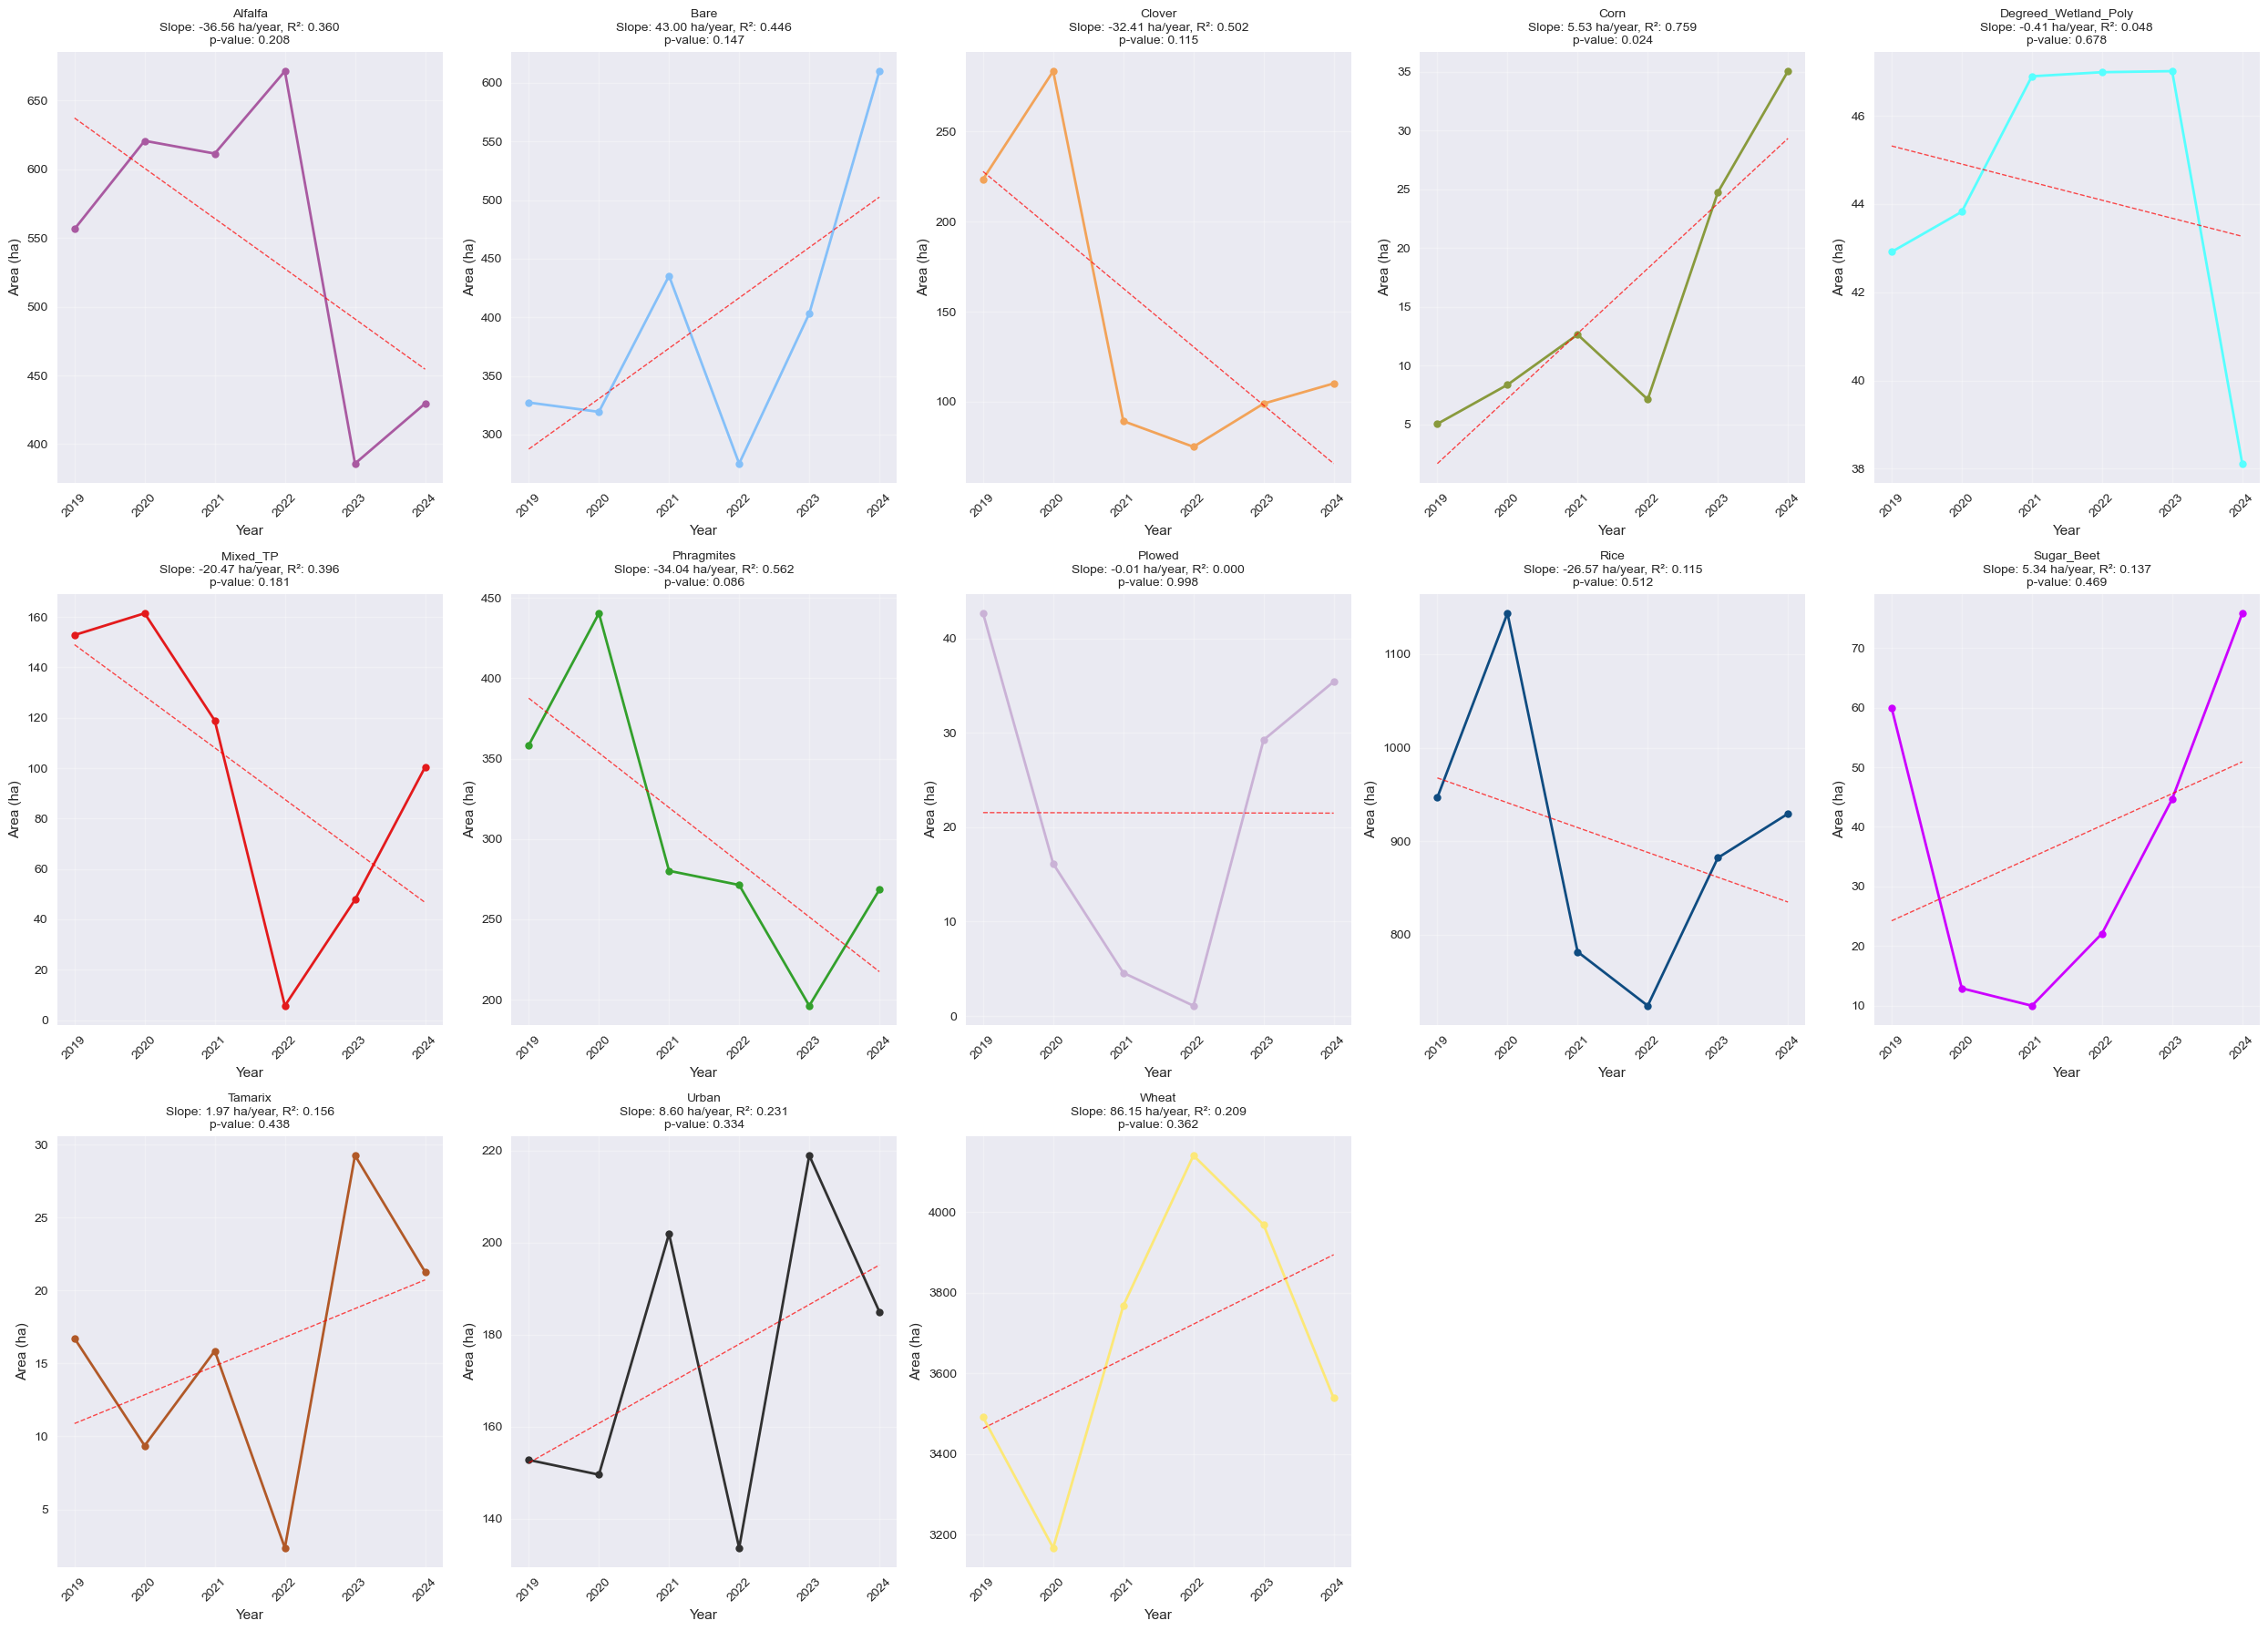


2. ANALYZING GROUP TRENDS (CROP, WETLAND, URBAN, Bare)


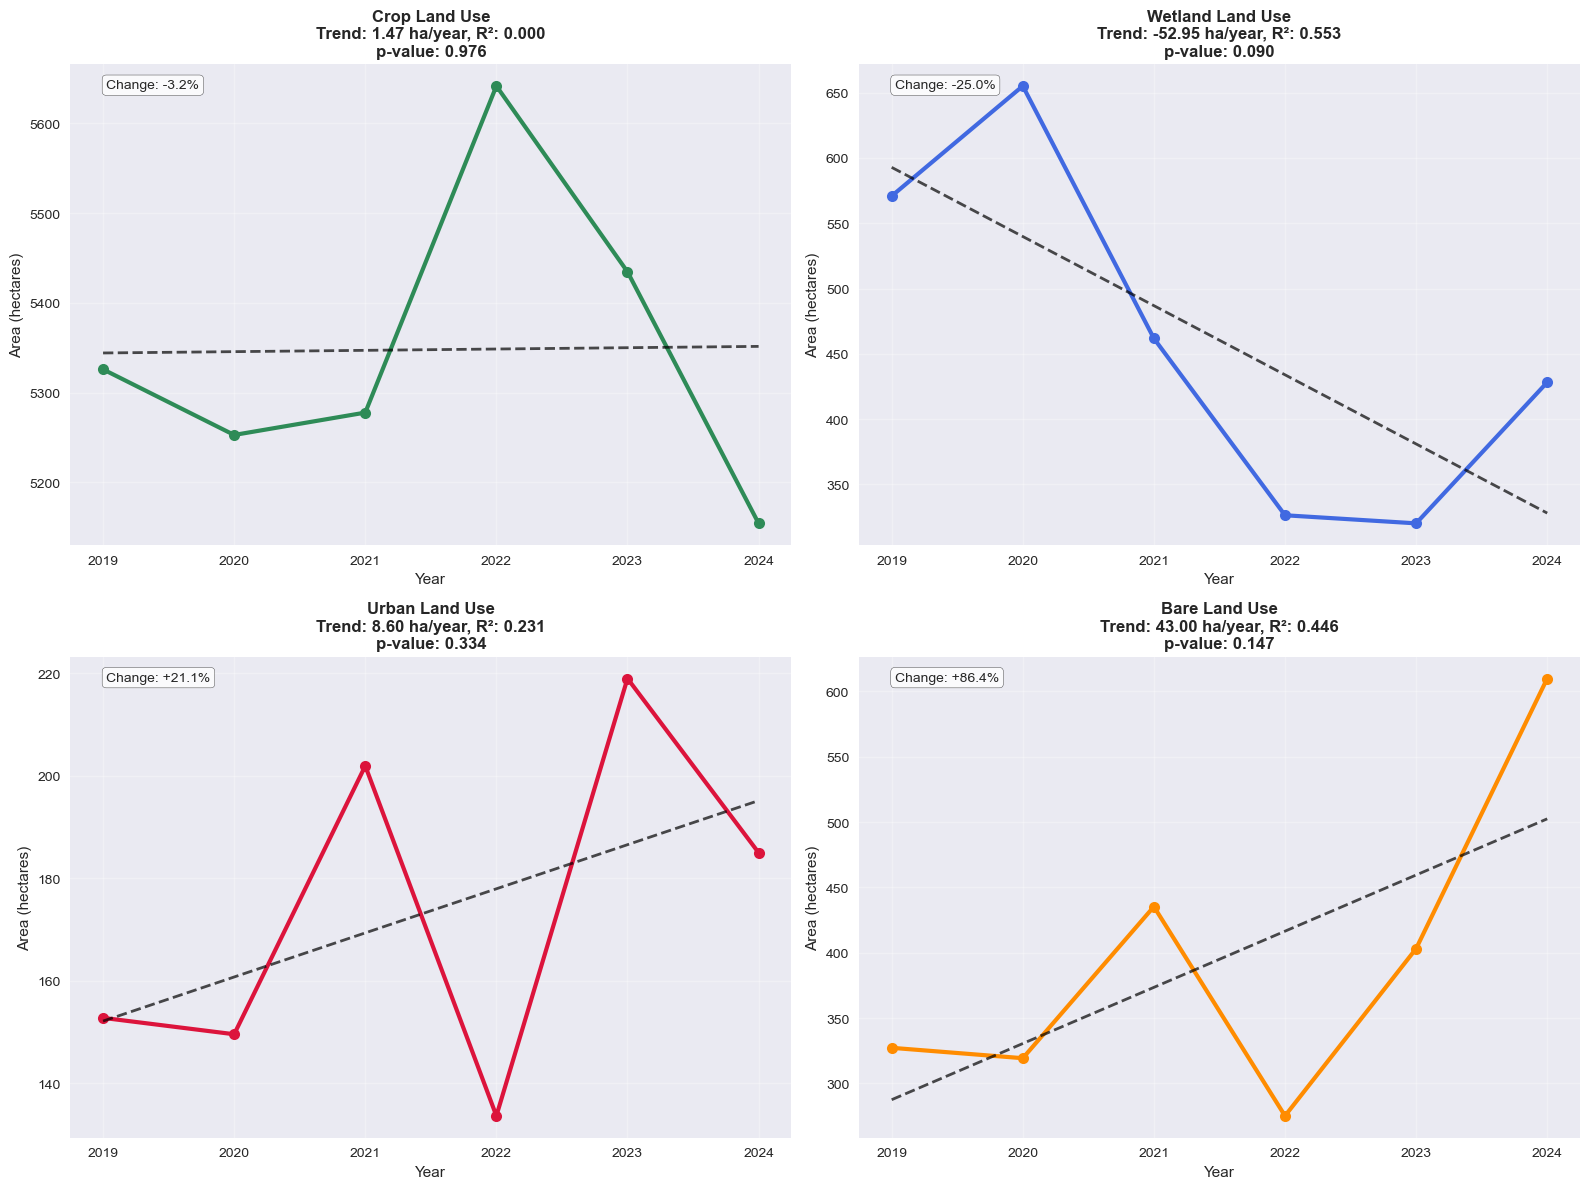


3. CREATING COMPARATIVE VISUALIZATIONS


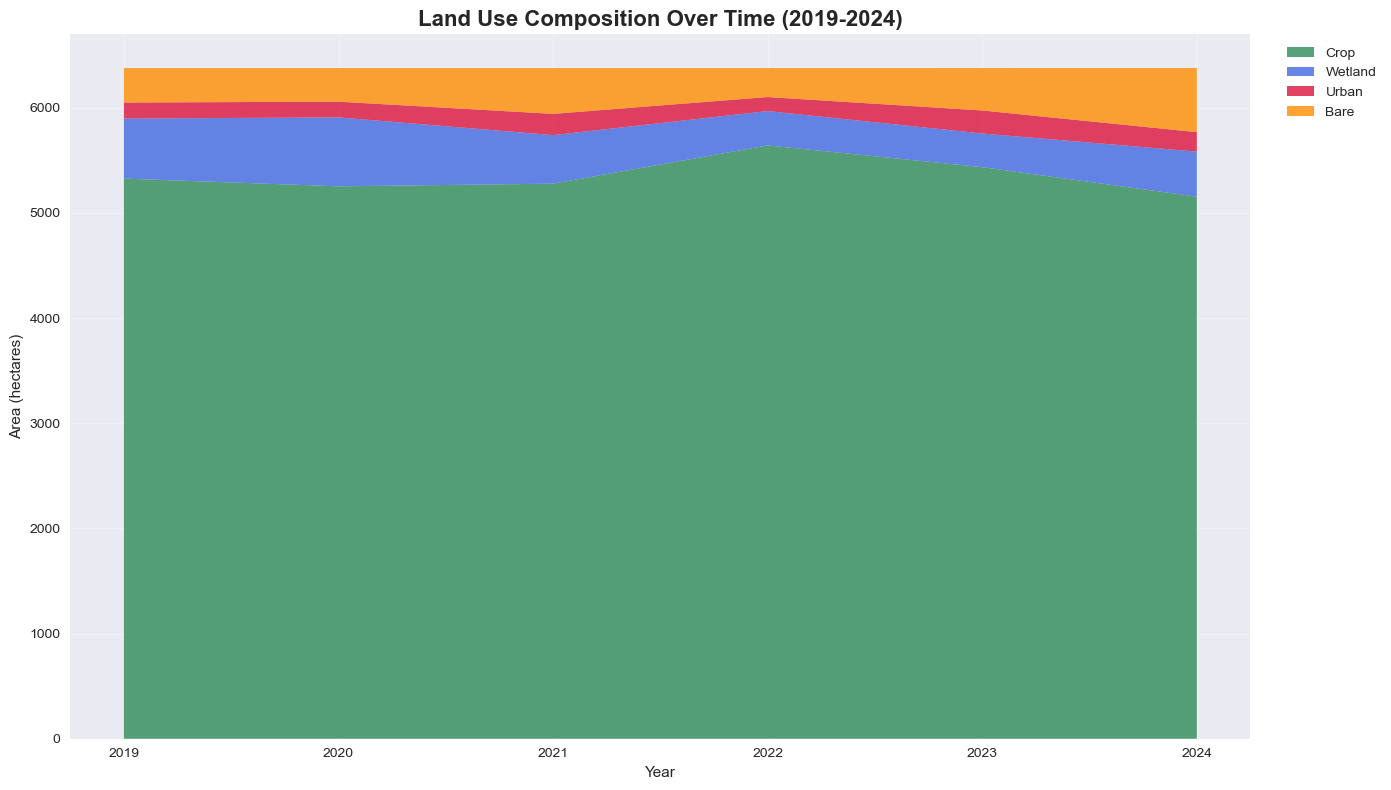

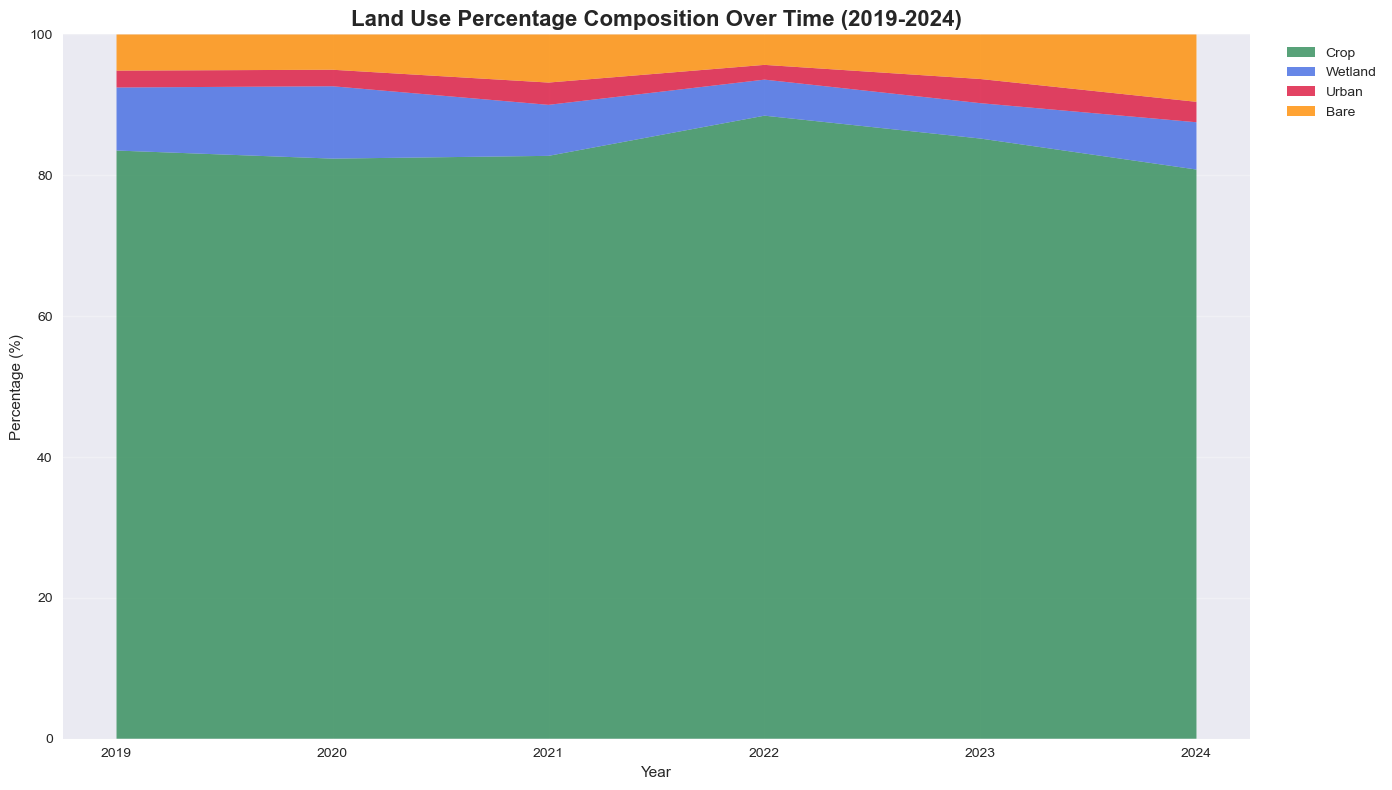

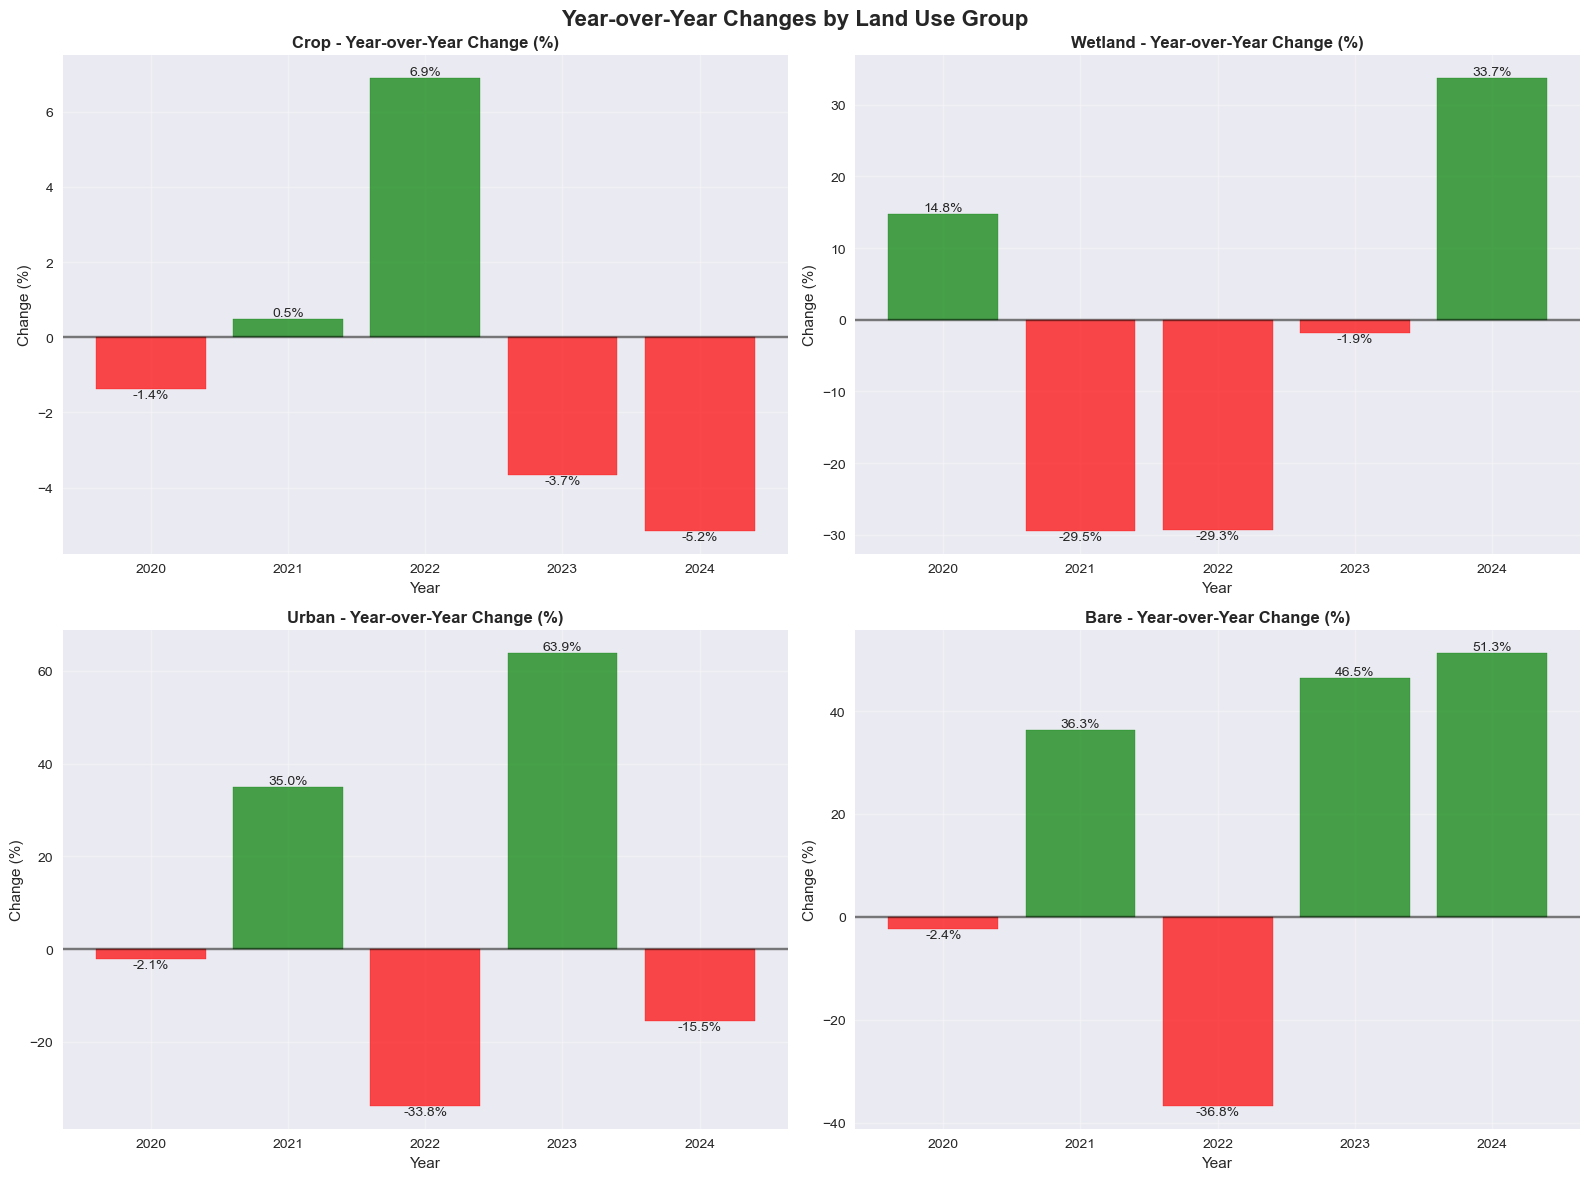


4. STATISTICAL SUMMARY
Individual Class Trends:
                                  slope r_squared   p_value       trend  \
Alfalfa-polygon              -36.557112  0.360305  0.207756  Decreasing   
Bare-polygon                  42.996839  0.445839  0.147278  Increasing   
Clover-polygon                -32.41306  0.501621  0.115259  Decreasing   
Corn-polygon                   5.527694  0.758596  0.023897  Increasing   
Degreed_Wetland_Poly-polygon  -0.409608  0.047607  0.677909  Decreasing   
Mixed_TP-polygon             -20.469394  0.395879  0.180758  Decreasing   
Phragmites-polygon           -34.040354  0.561922  0.086191  Decreasing   
Plowed-polygon                 -0.01132  0.000002  0.998124  Decreasing   
Rice-polygon                 -26.566447  0.114508  0.511789  Decreasing   
Sugar_Beet-polygon             5.336912  0.137407  0.469441  Increasing   
Tamarix-polygon                1.968427   0.15637  0.437763  Increasing   
Urban-polygon                  8.604768  0.231335  

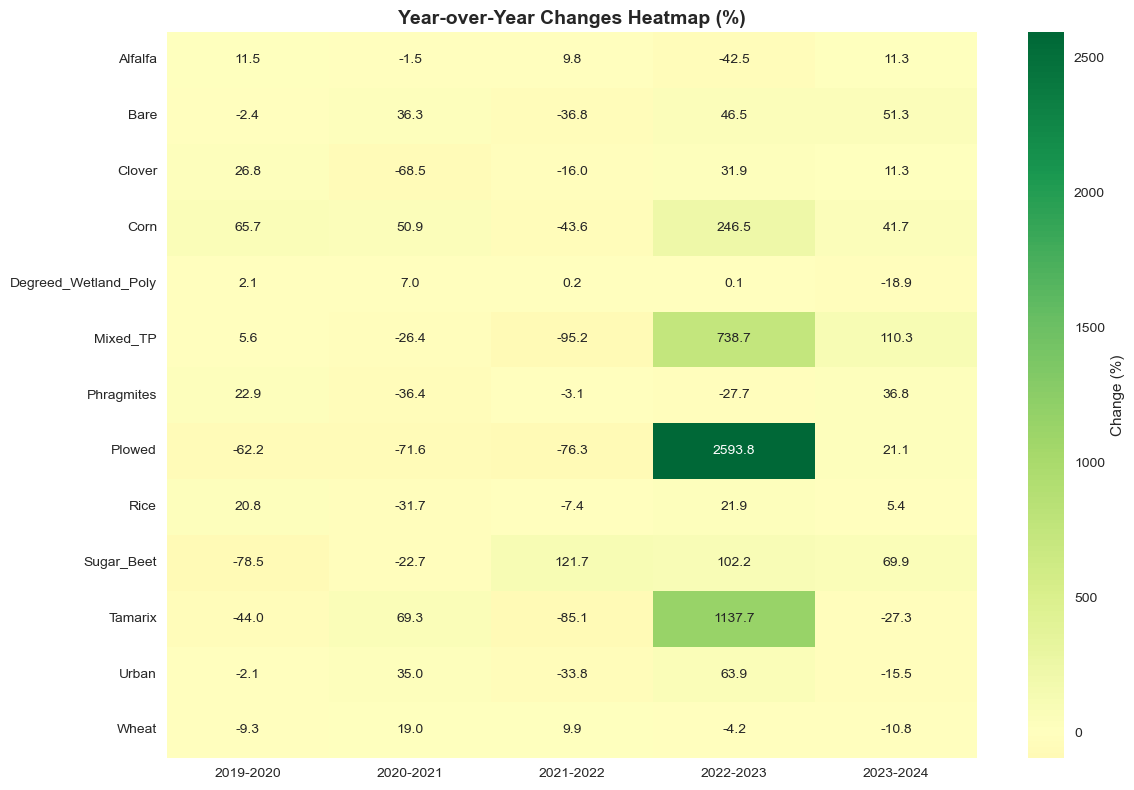

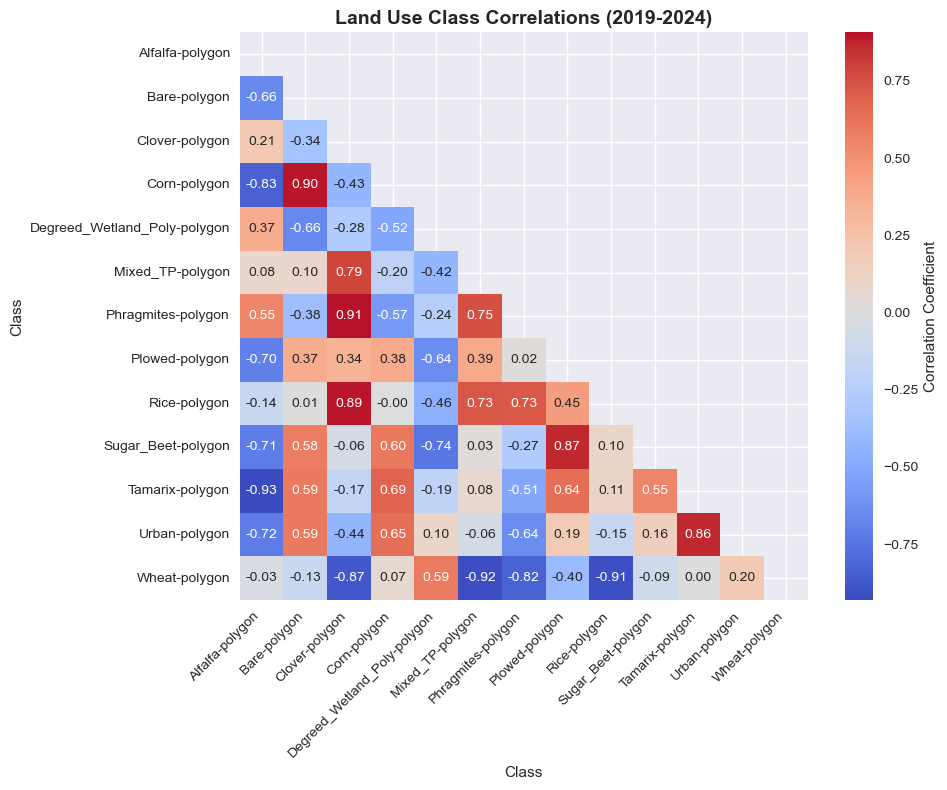


6. GENERATING SUMMARY REPORT
LULC TREND ANALYSIS REPORT (2019-2024)

OVERALL STATISTICS:
--------------------
2019: 6376.70 hectares
2020: 6376.71 hectares
2021: 6376.72 hectares
2022: 6376.72 hectares
2023: 6376.89 hectares
2024: 6377.42 hectares

GROUP TREND SUMMARY:
-------------------------
Crop:
  - Annual change: +1.47 ha/year
  - R-squared: 0.000
  - Trend: Increasing
  - P-value: 0.976

Wetland:
  - Annual change: -52.95 ha/year
  - R-squared: 0.553
  - Trend: Decreasing
  - P-value: 0.090

Urban:
  - Annual change: +8.60 ha/year
  - R-squared: 0.231
  - Trend: Increasing
  - P-value: 0.334

Bare:
  - Annual change: +43.00 ha/year
  - R-squared: 0.446
  - Trend: Increasing
  - P-value: 0.147

SIGNIFICANT INDIVIDUAL CLASS TRENDS:
----------------------------------------
Corn-polygon:
  - Annual change: +5.53 ha/year
  - R-squared: 0.759
  - P-value: 0.024


ANALYSIS COMPLETE!
All outputs saved to: F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__P

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy import stats
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Set up paths and style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
base_path = Path(r"F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__Predict")

# Years to analyze
years = ['2019', '2020', '2021', '2022', '2023', '2024']

# Define class groupings
class_groupings = {
    'Crop': ['Wheat-polygon', 'Rice-polygon', 'Alfalfa-polygon', 'Corn-polygon', 
             'Clover-polygon', 'Sugar_Beet-polygon', 'Plowed-polygon'],
    'Wetland': ['Phragmites-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Tamarix-polygon'],
    'Urban': ['Urban-polygon'],
    'Bare': ['Bare-polygon']
}

# Custom color palette for classes
custom_palette = {
    'Wheat-polygon': "#fce878",  
    'Rice-polygon': '#0f4c81',   
    'Alfalfa-polygon': '#a95aa1',
    'Bare-polygon': '#85c0f9',   
    'Phragmites-polygon': '#33a02c', 
    'Urban-polygon': "#313131",     
    'Clover-polygon': '#f2a359',    
    'Mixed_TP-polygon': '#e31a1c',  
    'Degreed_Wetland_Poly-polygon': "#57ffff", 
    'Tamarix-polygon': '#b15928',              
    'Corn-polygon': "#899a3d",                  
    'Sugar_Beet-polygon': "#cc00ff",            
    'Plowed-polygon': '#cab2d6',                
}

# Group colors
group_colors = {
    'Crop': '#2E8B57',      # SeaGreen
    'Wetland': '#4169E1',   # RoyalBlue
    'Urban': '#DC143C',     # Crimson
    'Bare': '#FF8C00'      # DarkOrange
}

print("="*60)
print("LULC TREND ANALYSIS 2019-2024")
print("="*60)

# Function to load data for all years
def load_yearly_data():
    yearly_data = {}
    for year in years:
        try:
            file_path = base_path / f"Predictions_{year}_Enhanced_Seasonal" / "class_areas_summary.csv"
            if file_path.exists():
                df = pd.read_csv(file_path)
                yearly_data[year] = df
                print(f"✓ Loaded data for {year}: {len(df)} classes")
            else:
                print(f"✗ File not found for {year}: {file_path}")
        except Exception as e:
            print(f"✗ Error loading {year}: {e}")
    
    return yearly_data

# Load all data
yearly_data = load_yearly_data()

if not yearly_data:
    print("No data files found. Please check the file paths.")
    exit()

# Combine all years into a single DataFrame
print("\nCombining data...")
combined_data = []

for year, df in yearly_data.items():
    df_copy = df.copy()
    df_copy['Year'] = int(year)
    combined_data.append(df_copy)

df_all = pd.concat(combined_data, ignore_index=True)
print(f"Combined data shape: {df_all.shape}")

# Add group information
def assign_group(class_name):
    for group, classes in class_groupings.items():
        if class_name in classes:
            return group
    return 'Bare'

df_all['Group'] = df_all['Class'].apply(assign_group)

# Create output directory
output_dir = base_path / "Trend_Analysis_2019_2024"
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir}")

# ============================================================================
# 1. INDIVIDUAL CLASS TRENDS
# ============================================================================
print("\n" + "="*50)
print("1. ANALYZING INDIVIDUAL CLASS TRENDS")
print("="*50)

# Create trend analysis for each class
fig, axes = plt.subplots(3, 5, figsize=(25, 18))
axes = axes.flatten()

class_trends = {}
for i, class_name in enumerate(sorted(df_all['Class'].unique())):
    if i >= len(axes):
        break
    
    class_data = df_all[df_all['Class'] == class_name].sort_values('Year')
    
    if len(class_data) > 1:
        # Linear regression for trend
        X = class_data['Year'].values.reshape(-1, 1)
        y = class_data['Area_Hectares'].values
        
        reg = LinearRegression().fit(X, y)
        trend_slope = reg.coef_[0]
        r_squared = reg.score(X, y)
        
        # Statistical significance test
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            class_data['Year'], class_data['Area_Hectares']
        )
        
        class_trends[class_name] = {
            'slope': slope,
            'r_squared': r_squared,
            'p_value': p_value,
            'trend': 'Increasing' if slope > 0 else 'Decreasing',
            'significance': 'Significant' if p_value < 0.05 else 'Not Significant'
        }
        
        # Plot
        ax = axes[i]
        color = custom_palette.get(class_name, 'gray')
        
        ax.plot(class_data['Year'], class_data['Area_Hectares'], 
                'o-', color=color, linewidth=2, markersize=6)
        
        # Add trend line
        trend_y = reg.predict(X)
        ax.plot(class_data['Year'], trend_y, '--', color='red', alpha=0.7, linewidth=1)
        
        ax.set_title(f'{class_name.replace("-polygon", "")}\n'
                    f'Slope: {slope:.2f} ha/year, R²: {r_squared:.3f}\n'
                    f'p-value: {p_value:.3f}', fontsize=10)
        ax.set_xlabel('Year')
        ax.set_ylabel('Area (ha)')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(output_dir / "individual_class_trends.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2. GROUP-LEVEL ANALYSIS
# ============================================================================
print("\n" + "="*50)
print("2. ANALYZING GROUP TRENDS (CROP, WETLAND, URBAN, Bare)")
print("="*50)

# Aggregate by groups
group_data = df_all.groupby(['Year', 'Group'])['Area_Hectares'].sum().reset_index()

# Create group trend plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

group_trends = {}
for i, (group, color) in enumerate(group_colors.items()):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    group_subset = group_data[group_data['Group'] == group].sort_values('Year')
    
    if len(group_subset) > 1:
        # Calculate trend
        X = group_subset['Year'].values.reshape(-1, 1)
        y = group_subset['Area_Hectares'].values
        
        reg = LinearRegression().fit(X, y)
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            group_subset['Year'], group_subset['Area_Hectares']
        )
        
        group_trends[group] = {
            'slope': slope,
            'r_squared': r_value**2,
            'p_value': p_value,
            'trend': 'Increasing' if slope > 0 else 'Decreasing'
        }
        
        # Plot
        ax.plot(group_subset['Year'], group_subset['Area_Hectares'], 
                'o-', color=color, linewidth=3, markersize=8, label=group)
        
        # Add trend line
        trend_y = reg.predict(X)
        ax.plot(group_subset['Year'], trend_y, '--', color='black', alpha=0.7, linewidth=2)
        
        ax.set_title(f'{group} Land Use\n'
                    f'Trend: {slope:.2f} ha/year, R²: {r_value**2:.3f}\n'
                    f'p-value: {p_value:.3f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Area (hectares)')
        ax.grid(True, alpha=0.3)
        
        # Add percentage change
        if len(group_subset) >= 2:
            start_area = group_subset.iloc[0]['Area_Hectares']
            end_area = group_subset.iloc[-1]['Area_Hectares']
            pct_change = ((end_area - start_area) / start_area) * 100 if start_area > 0 else 0
            ax.text(0.05, 0.95, f'Change: {pct_change:+.1f}%', 
                   transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(output_dir / "group_trends.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. COMPARATIVE ANALYSIS PLOTS
# ============================================================================
print("\n" + "="*50)
print("3. CREATING COMPARATIVE VISUALIZATIONS")
print("="*50)

# 3.1 Stacked Area Chart
plt.figure(figsize=(14, 8))
pivot_data = group_data.pivot(index='Year', columns='Group', values='Area_Hectares').fillna(0)

plt.stackplot(pivot_data.index, 
              pivot_data['Crop'], 
              pivot_data['Wetland'], 
              pivot_data['Urban'], 
              pivot_data['Bare'],
              labels=['Crop', 'Wetland', 'Urban', 'Bare'],
              colors=[group_colors[group] for group in ['Crop', 'Wetland', 'Urban', 'Bare']],
              alpha=0.8)

plt.title('Land Use Composition Over Time (2019-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Area (hectares)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "stacked_area_chart.png", dpi=300, bbox_inches='tight')
plt.show()

# 3.2 Percentage Composition
plt.figure(figsize=(14, 8))
pivot_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

plt.stackplot(pivot_pct.index, 
              pivot_pct['Crop'], 
              pivot_pct['Wetland'], 
              pivot_pct['Urban'], 
              pivot_pct['Bare'],
              labels=['Crop', 'Wetland', 'Urban', 'Bare'],
              colors=[group_colors[group] for group in ['Crop', 'Wetland', 'Urban', 'Bare']],
              alpha=0.8)

plt.title('Land Use Percentage Composition Over Time (2019-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "percentage_composition.png", dpi=300, bbox_inches='tight')
plt.show()

# 3.3 Year-over-Year Change Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Year-over-Year Changes by Land Use Group', fontsize=16, fontweight='bold')

for i, (group, color) in enumerate(group_colors.items()):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    group_subset = group_data[group_data['Group'] == group].sort_values('Year')
    
    if len(group_subset) > 1:
        # Calculate year-over-year changes
        yoy_changes = group_subset['Area_Hectares'].pct_change() * 100
        years_change = group_subset['Year'].iloc[1:]
        
        bars = ax.bar(years_change, yoy_changes.iloc[1:], color=color, alpha=0.7)
        
        # Color bars based on positive/negative change
        for bar, change in zip(bars, yoy_changes.iloc[1:]):
            if change >= 0:
                bar.set_color('green')
            else:
                bar.set_color('red')
        
        ax.set_title(f'{group} - Year-over-Year Change (%)', fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Change (%)')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.savefig(output_dir / "year_over_year_changes.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. STATISTICAL SUMMARY
# ============================================================================
print("\n" + "="*50)
print("4. STATISTICAL SUMMARY")
print("="*50)

# Create comprehensive summary tables
individual_summary = pd.DataFrame(class_trends).T
individual_summary = individual_summary.round(4)

group_summary = pd.DataFrame(group_trends).T
group_summary = group_summary.round(4)

print("Individual Class Trends:")
print("=" * 40)
print(individual_summary)

print("\nGroup Trends:")
print("=" * 20)
print(group_summary)

# Save summaries
individual_summary.to_csv(output_dir / "individual_class_trends_summary.csv")
group_summary.to_csv(output_dir / "group_trends_summary.csv")

# ============================================================================
# 5. ADVANCED VISUALIZATIONS
# ============================================================================
print("\n" + "="*50)
print("5. CREATING ADVANCED VISUALIZATIONS")
print("="*50)

# 5.1 Heatmap of changes
plt.figure(figsize=(12, 8))

# Create matrix of year-over-year changes for all classes
change_matrix = []
classes = sorted(df_all['Class'].unique())

for class_name in classes:
    class_data = df_all[df_all['Class'] == class_name].sort_values('Year')
    if len(class_data) > 1:
        changes = class_data['Area_Hectares'].pct_change().iloc[1:] * 100
        change_matrix.append(changes.values)
    else:
        change_matrix.append([0] * (len(years) - 1))

change_df = pd.DataFrame(change_matrix, 
                        index=[c.replace('-polygon', '') for c in classes],
                        columns=[f'{years[i]}-{years[i+1]}' for i in range(len(years)-1)])

sns.heatmap(change_df, annot=True, cmap='RdYlGn', center=0, 
            fmt='.1f', cbar_kws={'label': 'Change (%)'})
plt.title('Year-over-Year Changes Heatmap (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / "changes_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# 5.2 Correlation Analysis
plt.figure(figsize=(10, 8))

# Create correlation matrix between different land use classes
correlation_data = df_all.pivot(index='Year', columns='Class', values='Area_Hectares')
correlation_matrix = correlation_data.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Land Use Class Correlations (2019-2024)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / "correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. SUMMARY REPORT
# ============================================================================
print("\n" + "="*50)
print("6. GENERATING SUMMARY REPORT")
print("="*50)

# Generate comprehensive report
report = []
report.append("LULC TREND ANALYSIS REPORT (2019-2024)")
report.append("=" * 50)
report.append("")

# Overall statistics
total_area_by_year = df_all.groupby('Year')['Area_Hectares'].sum()
report.append("OVERALL STATISTICS:")
report.append("-" * 20)
for year in years:
    if int(year) in total_area_by_year.index:
        report.append(f"{year}: {total_area_by_year[int(year)]:.2f} hectares")

report.append("")
report.append("GROUP TREND SUMMARY:")
report.append("-" * 25)
for group, stats in group_trends.items():
    report.append(f"{group}:")
    report.append(f"  - Annual change: {stats['slope']:+.2f} ha/year")
    report.append(f"  - R-squared: {stats['r_squared']:.3f}")
    report.append(f"  - Trend: {stats['trend']}")
    report.append(f"  - P-value: {stats['p_value']:.3f}")
    report.append("")

report.append("SIGNIFICANT INDIVIDUAL CLASS TRENDS:")
report.append("-" * 40)
significant_trends = [(k, v) for k, v in class_trends.items() if v['p_value'] < 0.05]
for class_name, stats in significant_trends:
    report.append(f"{class_name}:")
    report.append(f"  - Annual change: {stats['slope']:+.2f} ha/year")
    report.append(f"  - R-squared: {stats['r_squared']:.3f}")
    report.append(f"  - P-value: {stats['p_value']:.3f}")
    report.append("")

# Save report
with open(output_dir / "trend_analysis_report.txt", 'w') as f:
    f.write('\n'.join(report))

print('\n'.join(report))

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"All outputs saved to: {output_dir}")
print("\nGenerated files:")
print("- individual_class_trends.png")
print("- group_trends.png") 
print("- stacked_area_chart.png")
print("- percentage_composition.png")
print("- year_over_year_changes.png")
print("- changes_heatmap.png")
print("- correlation_matrix.png")
print("- individual_class_trends_summary.csv")
print("- group_trends_summary.csv")
print("- trend_analysis_report.txt")

In [6]:
# # Just to create 2024 Area CSV 

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import geopandas as gpd
# from pathlib import Path
# import warnings
# from scipy import stats
# from sklearn.linear_model import LinearRegression
# from shapely import wkt
# import json
# warnings.filterwarnings('ignore')

# # Set up paths and style
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")
# base_path = Path(r"F:\_____My_Thesies____")

# # 2024 specific paths
# enhanced_2024_path = base_path / "Implimantation" / "3.Train_Model" / "6.Adding_Phenology" / "Enhanced_Classification_Results_50-50" / "final_dataset_enhanced_all.csv"
# seg_2024_path = base_path / "_ImpFiles" / "3. Feature Selection" / "_Sentinel Data" / "2. Divided Data" / "6.Segmentation" / "Seg_2024" / "segmentation_layer.shp"

# # Output path for 2024
# output_2024_dir = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict" / "Predictions_2024_Enhanced_Seasonal"
# output_2024_dir.mkdir(parents=True, exist_ok=True)

# # Trend analysis output
# trend_output_dir = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict" / "Trend_Analysis_2019_2024"
# trend_output_dir.mkdir(parents=True, exist_ok=True)

# # Custom color palette
# custom_palette = {
#     'Wheat-polygon': "#fce878",  
#     'Rice-polygon': '#0f4c81',   
#     'Alfalfa-polygon': '#a95aa1',
#     'Bare-polygon': '#85c0f9',   
#     'Phragmites-polygon': '#33a02c', 
#     'Urban-polygon': "#313131",     
#     'Clover-polygon': '#f2a359',    
#     'Mixed_TP-polygon': '#e31a1c',  
#     'Degreed_Wetland_Poly-polygon': "#57ffff", 
#     'Tamarix-polygon': '#b15928',              
#     'Corn-polygon': "#899a3d",                  
#     'Sugar_Beet-polygon': "#cc00ff",            
#     'Plowed-polygon': '#cab2d6',                
# }

# # Define class groupings
# class_groupings = {
#     'Crop': ['Wheat-polygon', 'Rice-polygon', 'Alfalfa-polygon', 'Corn-polygon', 
#              'Clover-polygon', 'Sugar_Beet-polygon', 'Plowed-polygon'],
#     'Wetland': ['Phragmites-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon'],
#     'Urban': ['Urban-polygon'],
#     'Other': ['Bare-polygon', 'Tamarix-polygon']
# }

# # Group colors
# group_colors = {
#     'Crop': '#2E8B57',      # SeaGreen
#     'Wetland': '#4169E1',   # RoyalBlue
#     'Urban': '#DC143C',     # Crimson
#     'Other': '#FF8C00'      # DarkOrange
# }

# print("="*60)
# print("PROCESSING 2024 DATA AND TREND ANALYSIS")
# print("="*60)

# # ============================================================================
# # STEP 1: PROCESS 2024 DATA
# # ============================================================================
# print("\n" + "="*50)
# print("STEP 1: PROCESSING 2024 DATA")
# print("="*50)

# print("Loading 2024 enhanced dataset...")
# df_2024 = pd.read_csv(enhanced_2024_path)
# print(f"2024 data shape: {df_2024.shape}")
# print(f"2024 columns: {list(df_2024.columns)}")

# print("\nLoading 2024 segmentation layer...")
# gdf_seg_2024 = gpd.read_file(seg_2024_path)
# print(f"2024 segmentation shape: {gdf_seg_2024.shape}")
# print(f"2024 segmentation columns: {list(gdf_seg_2024.columns)}")

# # Handle geometry column in 2024 data
# if 'geometry' in df_2024.columns:
#     print("Found geometry column in 2024 data, processing...")
    
#     # Check if geometries are stored as text
#     sample_geom = df_2024['geometry'].dropna().iloc[0] if not df_2024['geometry'].dropna().empty else None
    
#     if sample_geom and isinstance(sample_geom, str):
#         print("Converting WKT strings to shapely objects...")
#         def safe_wkt_loads(geom_str):
#             if pd.isna(geom_str) or geom_str == '':
#                 return None
#             try:
#                 return wkt.loads(geom_str)
#             except:
#                 return None
        
#         df_2024['geometry'] = df_2024['geometry'].apply(safe_wkt_loads)
    
#     # Create GeoDataFrame
#     try:
#         gdf_2024 = gpd.GeoDataFrame(df_2024, geometry='geometry')
#         missing_geom = gdf_2024['geometry'].isna().sum()
#         print(f"Missing geometries in 2024 data: {missing_geom}")
#     except Exception as e:
#         print(f"Error creating GeoDataFrame: {e}")
#         gdf_2024 = df_2024.copy()
#         missing_geom = len(df_2024)
# else:
#     print("No geometry column found in 2024 data")
#     gdf_2024 = df_2024.copy()
#     missing_geom = len(df_2024)

# # Merge with segmentation data if needed
# if missing_geom > 0 and 'PXLVAL' in df_2024.columns and 'PXLVAL' in gdf_seg_2024.columns:
#     print("Merging with segmentation data to fill missing geometries...")
    
#     gdf_merged = gdf_2024.merge(
#         gdf_seg_2024[['PXLVAL', 'geometry']], 
#         on='PXLVAL', 
#         how='left', 
#         suffixes=('', '_seg')
#     )
    
#     # Fill missing geometries
#     if 'geometry' in gdf_merged.columns and 'geometry_seg' in gdf_merged.columns:
#         mask = gdf_merged['geometry'].isna()
#         gdf_merged.loc[mask, 'geometry'] = gdf_merged.loc[mask, 'geometry_seg']
#         gdf_merged = gdf_merged.drop('geometry_seg', axis=1)
#     elif 'geometry_seg' in gdf_merged.columns:
#         gdf_merged['geometry'] = gdf_merged['geometry_seg']
#         gdf_merged = gdf_merged.drop('geometry_seg', axis=1)
    
#     # Create final GeoDataFrame
#     try:
#         gdf_2024_final = gpd.GeoDataFrame(gdf_merged, geometry='geometry', crs=gdf_seg_2024.crs)
#         final_missing_geom = gdf_2024_final['geometry'].isna().sum()
#         print(f"Remaining missing geometries: {final_missing_geom}")
#     except Exception as e:
#         print(f"Error creating final GeoDataFrame: {e}")
#         gdf_2024_final = gdf_2024.copy()
# else:
#     gdf_2024_final = gdf_2024.copy()

# # Identify prediction column for 2024
# pred_cols_2024 = [col for col in gdf_2024_final.columns if 'pred' in col.lower() or 'layer' in col.lower()]
# print(f"Potential prediction columns: {pred_cols_2024}")

# # Use predicted_layer or layer column
# if 'predicted_layer' in gdf_2024_final.columns:
#     pred_col_2024 = 'predicted_layer'
# elif 'layer' in gdf_2024_final.columns:
#     pred_col_2024 = 'layer'
# else:
#     pred_col_2024 = pred_cols_2024[0] if pred_cols_2024 else None

# print(f"Using prediction column: {pred_col_2024}")

# # Calculate areas for 2024
# if pred_col_2024 and 'geometry' in gdf_2024_final.columns:
#     print("\nCalculating areas for 2024...")
    
#     # Check and transform CRS if needed
#     if gdf_2024_final.crs and gdf_2024_final.crs.is_geographic:
#         print("Converting from geographic to projected CRS for area calculation...")
#         gdf_2024_proj = gdf_2024_final.to_crs('EPSG:32639')  # UTM Zone 39N
#         area_gdf = gdf_2024_proj
#     else:
#         area_gdf = gdf_2024_final
    
#     # Calculate areas
#     area_gdf_clean = area_gdf.dropna(subset=[pred_col_2024, 'geometry']).copy()
#     area_gdf_clean['area_m2'] = area_gdf_clean.geometry.area
#     area_gdf_clean['area_ha'] = area_gdf_clean['area_m2'] / 10000
    
#     # Group by class and sum areas
#     class_areas_2024 = area_gdf_clean.groupby(pred_col_2024)['area_ha'].sum().sort_values(ascending=False)
    
#     print("2024 Class Areas (Hectares):")
#     print("-" * 30)
#     total_area = 0
#     for class_val, area in class_areas_2024.items():
#         print(f"Class {class_val}: {area:.2f} ha")
#         total_area += area
#     print(f"\nTotal Area 2024: {total_area:.2f} ha")
    
#     # Create 2024 class areas summary CSV
#     class_areas_2024_df = pd.DataFrame({
#         'Class': class_areas_2024.index,
#         'Area_Hectares': class_areas_2024.values,
#         'Percentage': (class_areas_2024.values / class_areas_2024.sum() * 100)
#     })
    
#     # Save 2024 class areas
#     class_areas_2024_path = output_2024_dir / "class_areas_summary.csv"
#     class_areas_2024_df.to_csv(class_areas_2024_path, index=False)
#     print(f"2024 class areas saved to: {class_areas_2024_path}")
    
#     # Save processed 2024 data
#     processed_2024_shp = output_2024_dir / "predictions_2024_with_geometry.shp"
#     gdf_2024_final.to_file(processed_2024_shp)
#     print(f"2024 processed data saved to: {processed_2024_shp}")

# else:
#     print("Cannot calculate areas for 2024 - missing geometry or prediction column")

# # ============================================================================
# # STEP 2: LOAD ALL YEARS DATA FOR TREND ANALYSIS
# # ============================================================================
# print("\n" + "="*50)
# print("STEP 2: LOADING ALL YEARS FOR TREND ANALYSIS")
# print("="*50)

# years = ['2019', '2020', '2021', '2022', '2023', '2024']
# yearly_data = {}

# # Load data for 2019-2023 from existing files
# predict_base_path = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict"

# for year in years[:-1]:  # 2019-2023
#     try:
#         file_path = predict_base_path / f"Predictions_{year}_Enhanced_Seasonal" / "class_areas_summary.csv"
#         if file_path.exists():
#             df = pd.read_csv(file_path)
#             yearly_data[year] = df
#             print(f"✓ Loaded data for {year}: {len(df)} classes")
#         else:
#             print(f"✗ File not found for {year}: {file_path}")
#     except Exception as e:
#         print(f"✗ Error loading {year}: {e}")

# # Add 2024 data
# if 'class_areas_2024_df' in locals():
#     yearly_data['2024'] = class_areas_2024_df
#     print(f"✓ Added 2024 data: {len(class_areas_2024_df)} classes")

# print(f"\nTotal years loaded: {len(yearly_data)}")

# if len(yearly_data) < 2:
#     print("Need at least 2 years of data for trend analysis")
#     exit()

# # ============================================================================
# # STEP 3: TREND ANALYSIS
# # ============================================================================
# print("\n" + "="*50)
# print("STEP 3: PERFORMING TREND ANALYSIS")
# print("="*50)

# # Combine all years into a single DataFrame
# combined_data = []
# for year, df in yearly_data.items():
#     df_copy = df.copy()
#     df_copy['Year'] = int(year)
#     combined_data.append(df_copy)

# df_all = pd.concat(combined_data, ignore_index=True)
# print(f"Combined data shape: {df_all.shape}")

# # Add group information
# def assign_group(class_name):
#     for group, classes in class_groupings.items():
#         if class_name in classes:
#             return group
#     return 'Other'

# df_all['Group'] = df_all['Class'].apply(assign_group)

# # ============================================================================
# # VISUALIZATION 1: INDIVIDUAL CLASS TRENDS
# # ============================================================================
# print("Creating individual class trend visualizations...")

# fig, axes = plt.subplots(3, 5, figsize=(25, 18))
# axes = axes.flatten()

# class_trends = {}
# available_years = sorted(df_all['Year'].unique())

# for i, class_name in enumerate(sorted(df_all['Class'].unique())):
#     if i >= len(axes):
#         break
    
#     class_data = df_all[df_all['Class'] == class_name].sort_values('Year')
    
#     if len(class_data) > 1:
#         # Linear regression for trend
#         X = class_data['Year'].values.reshape(-1, 1)
#         y = class_data['Area_Hectares'].values
        
#         reg = LinearRegression().fit(X, y)
#         slope, intercept, r_value, p_value, std_err = stats.linregress(
#             class_data['Year'], class_data['Area_Hectares']
#         )
        
#         class_trends[class_name] = {
#             'slope': slope,
#             'r_squared': r_value**2,
#             'p_value': p_value,
#             'trend': 'Increasing' if slope > 0 else 'Decreasing',
#             'significance': 'Significant' if p_value < 0.05 else 'Not Significant'
#         }
        
#         # Plot
#         ax = axes[i]
#         color = custom_palette.get(class_name, 'gray')
        
#         ax.plot(class_data['Year'], class_data['Area_Hectares'], 
#                 'o-', color=color, linewidth=2, markersize=6)
        
#         # Add trend line
#         trend_y = reg.predict(X)
#         ax.plot(class_data['Year'], trend_y, '--', color='red', alpha=0.7, linewidth=1)
        
#         ax.set_title(f'{class_name.replace("-polygon", "")}\n'
#                     f'Slope: {slope:.2f} ha/year, R²: {r_value**2:.3f}\n'
#                     f'p-value: {p_value:.3f}', fontsize=10)
#         ax.set_xlabel('Year')
#         ax.set_ylabel('Area (ha)')
#         ax.grid(True, alpha=0.3)
#         ax.set_xticks(available_years)

# # Remove empty subplots
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle('Individual LULC Class Trends (2019-2024)', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.savefig(trend_output_dir / "individual_class_trends.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # VISUALIZATION 2: GROUP-LEVEL ANALYSIS
# # ============================================================================
# print("Creating group-level trend analysis...")

# # Aggregate by groups
# group_data = df_all.groupby(['Year', 'Group'])['Area_Hectares'].sum().reset_index()

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# group_trends = {}

# for i, (group, color) in enumerate(group_colors.items()):
#     row, col = i // 2, i % 2
#     ax = axes[row, col]
    
#     group_subset = group_data[group_data['Group'] == group].sort_values('Year')
    
#     if len(group_subset) > 1:
#         # Calculate trend
#         X = group_subset['Year'].values.reshape(-1, 1)
#         y = group_subset['Area_Hectares'].values
        
#         reg = LinearRegression().fit(X, y)
#         slope, intercept, r_value, p_value, std_err = stats.linregress(
#             group_subset['Year'], group_subset['Area_Hectares']
#         )
        
#         group_trends[group] = {
#             'slope': slope,
#             'r_squared': r_value**2,
#             'p_value': p_value,
#             'trend': 'Increasing' if slope > 0 else 'Decreasing'
#         }
        
#         # Plot
#         ax.plot(group_subset['Year'], group_subset['Area_Hectares'], 
#                 'o-', color=color, linewidth=3, markersize=8, label=group)
        
#         # Add trend line
#         trend_y = reg.predict(X)
#         ax.plot(group_subset['Year'], trend_y, '--', color='black', alpha=0.7, linewidth=2)
        
#         ax.set_title(f'{group} Land Use\n'
#                     f'Trend: {slope:.2f} ha/year, R²: {r_value**2:.3f}\n'
#                     f'p-value: {p_value:.3f}', fontsize=12, fontweight='bold')
#         ax.set_xlabel('Year')
#         ax.set_ylabel('Area (hectares)')
#         ax.grid(True, alpha=0.3)
#         ax.set_xticks(available_years)
        
#         # Add percentage change
#         if len(group_subset) >= 2:
#             start_area = group_subset.iloc[0]['Area_Hectares']
#             end_area = group_subset.iloc[-1]['Area_Hectares']
#             pct_change = ((end_area - start_area) / start_area) * 100 if start_area > 0 else 0
#             ax.text(0.05, 0.95, f'Change: {pct_change:+.1f}%', 
#                    transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# plt.suptitle('Land Use Group Trends (2019-2024)', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.savefig(trend_output_dir / "group_trends.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # VISUALIZATION 3: STACKED AREA CHART
# # ============================================================================
# print("Creating stacked area chart...")

# plt.figure(figsize=(14, 8))
# pivot_data = group_data.pivot(index='Year', columns='Group', values='Area_Hectares').fillna(0)

# plt.stackplot(pivot_data.index, 
#               pivot_data['Crop'], 
#               pivot_data['Wetland'], 
#               pivot_data['Urban'], 
#               pivot_data['Other'],
#               labels=['Crop', 'Wetland', 'Urban', 'Other'],
#               colors=[group_colors[group] for group in ['Crop', 'Wetland', 'Urban', 'Other']],
#               alpha=0.8)

# plt.title('Land Use Composition Over Time (2019-2024)', fontsize=16, fontweight='bold')
# plt.xlabel('Year')
# plt.ylabel('Area (hectares)')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True, alpha=0.3)
# plt.xticks(available_years)
# plt.tight_layout()
# plt.savefig(trend_output_dir / "stacked_area_chart.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ============================================================================
# # STATISTICAL SUMMARY AND REPORT
# # ============================================================================
# print("Generating statistical summary...")

# # Create comprehensive summary tables
# if class_trends:
#     individual_summary = pd.DataFrame(class_trends).T
#     individual_summary = individual_summary.round(4)
#     individual_summary.to_csv(trend_output_dir / "individual_class_trends_summary.csv")

# if group_trends:
#     group_summary = pd.DataFrame(group_trends).T
#     group_summary = group_summary.round(4)
#     group_summary.to_csv(trend_output_dir / "group_trends_summary.csv")

# # Generate report
# report = []
# report.append("LULC TREND ANALYSIS REPORT (2019-2024)")
# report.append("=" * 50)
# report.append("")
# report.append(f"Analysis includes {len(yearly_data)} years: {', '.join(yearly_data.keys())}")
# report.append("")

# # Overall statistics
# total_area_by_year = df_all.groupby('Year')['Area_Hectares'].sum()
# report.append("OVERALL STATISTICS:")
# report.append("-" * 20)
# for year in available_years:
#     if year in total_area_by_year.index:
#         report.append(f"{year}: {total_area_by_year[year]:.2f} hectares")

# report.append("")
# report.append("GROUP TREND SUMMARY:")
# report.append("-" * 25)
# for group, stats in group_trends.items():
#     report.append(f"{group}:")
#     report.append(f"  - Annual change: {stats['slope']:+.2f} ha/year")
#     report.append(f"  - R-squared: {stats['r_squared']:.3f}")
#     report.append(f"  - Trend: {stats['trend']}")
#     report.append(f"  - P-value: {stats['p_value']:.3f}")
#     report.append("")

# # Save report
# with open(trend_output_dir / "trend_analysis_report.txt", 'w') as f:
#     f.write('\n'.join(report))

# print('\n'.join(report))

# print("\n" + "="*60)
# print("ANALYSIS COMPLETE!")
# print("="*60)
# print(f"2024 results saved to: {output_2024_dir}")
# print(f"Trend analysis saved to: {trend_output_dir}")
# print("\nGenerated files:")
# print("- 2024 class_areas_summary.csv")
# print("- 2024 predictions_2024_with_geometry.shp")
# print("- individual_class_trends.png")
# print("- group_trends.png") 
# print("- stacked_area_chart.png")
# print("- individual_class_trends_summary.csv")
# print("- group_trends_summary.csv")
# print("- trend_analysis_report.txt")